<a href="https://colab.research.google.com/github/koko2585/fault-diagnosis/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Exploratory Data Analysis

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Loading Data

In [ ]:
df = pd.read_csv(r"/content/sample_data/feature_time_48k_2048_load_1.csv")

Exploring into the data

In [ ]:
df.head()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form,fault
0,0.35986,-0.41890,0.017840,0.122746,0.124006,-0.118571,-0.042219,2.901946,6.950855,Ball_007_1
1,0.46772,-0.36111,0.022255,0.132488,0.134312,0.174699,-0.081548,3.482334,6.035202,Ball_007_1
2,0.46855,-0.43809,0.020470,0.149651,0.151008,0.040339,-0.274069,3.102819,7.376926,Ball_007_1
3,0.58475,-0.54303,0.020960,0.157067,0.158422,-0.023266,0.134692,3.691097,7.558387,Ball_007_1
4,0.44685,-0.57891,0.022167,0.138189,0.139922,-0.081534,0.402783,3.193561,6.312085,Ball_007_1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2300 entries, 0 to 2299
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   max       2300 non-null   float64
 1   min       2300 non-null   float64
 2   mean      2300 non-null   float64
 3   sd        2300 non-null   float64
 4   rms       2300 non-null   float64
 5   skewness  2300 non-null   float64
 6   kurtosis  2300 non-null   float64
 7   crest     2300 non-null   float64
 8   form      2300 non-null   float64
 9   fault     2300 non-null   object 
dtypes: float64(9), object(1)
memory usage: 179.8+ KB


In [ ]:
df.describe()

,max,min,mean,sd,rms,skewness,kurtosis,crest,form
count,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000,2300.000000
mean,1.575079,-1.550994,0.015711,0.341601,0.342289,-0.042251,2.664444,4.173130,26.544769
std,1.578422,1.602706,0.006469,0.305279,0.304813,0.180774,4.411096,1.148349,29.209702
min,0.157300,-6.292600,0.003246,0.059140,0.061067,-1.089928,-0.803795,2.428511,3.484429
25%,0.456398,-2.174975,0.011236,0.135506,0.136374,-0.103426,-0.015164,3.260382,7.413359
50%,0.794510,-0.733700,0.013730,0.188551,0.190662,-0.002466,0.816970,3.921650,13.122811
75%,2.278425,-0.426987,0.018638,0.555589,0.555671,0.061093,3.902286,4.815876,39.911894
max,6.825900,-0.160220,0.038386,1.256577,1.256311,1.059512,30.385326,8.821577,313.742612


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("missing values: \n")
print(df.isnull().sum())

missing values: 

max         0
min         0
mean        0
sd          0
rms         0
skewness    0
kurtosis    0
crest       0
form        0
fault       0
dtype: int64


In [ ]:
print("target distribution\n")
df['fault'].value_counts()

target distribution



,count
fault,
Ball_007_1,230
Ball_014_1,230
Ball_021_1,230
IR_007_1,230
IR_014_1,230
IR_021_1,230
OR_007_6_1,230
OR_014_6_1,230
OR_021_6_1,230


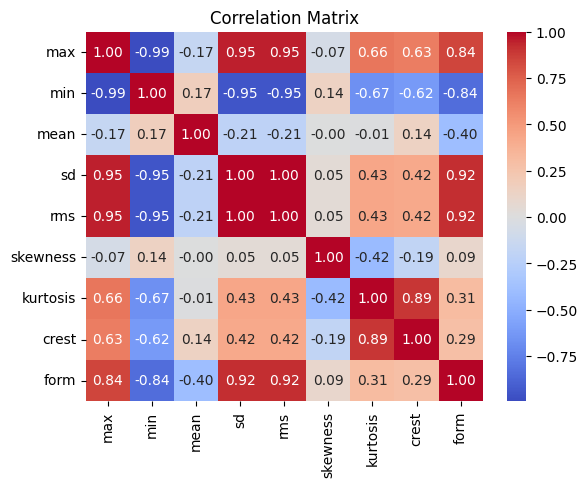

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Very high correlation: 'sd' and 'rms' are almost perfectly positively correlated in this dataset, suggesting substantial redundancy between the two features.   

Inverse Relationship: 'max' and 'min' show a perfect negative correlation ($-0.99$), which is logically expected in vibration signal features.   

Strong Feature Associations: Features like 'form' show high positive correlation with sd ($0.92$) and rms ($0.92$).

Similarly, 'kurtosis' and 'crest' factor share a strong positive correlation ($0.89$).   

Low Correlation: Features like 'mean' and 'skewness' exhibit weak correlations with most other features, suggesting they capture distinct, independent characteristics of the dataset.   

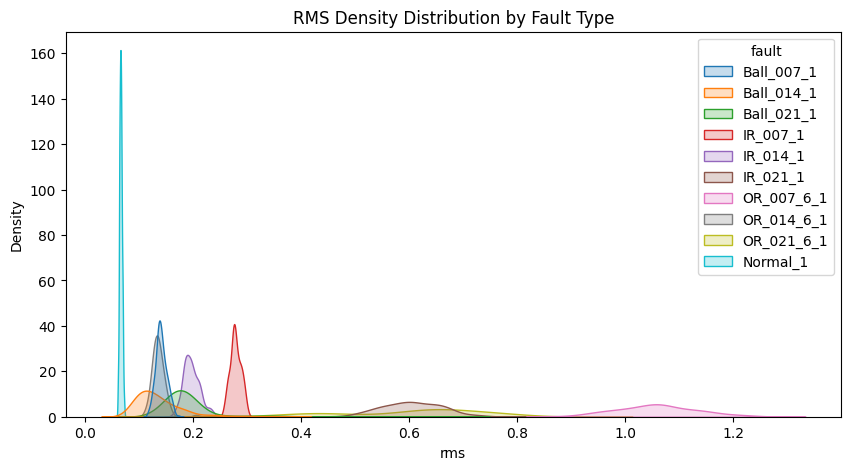

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='rms', hue='fault', common_norm=False, fill=True)
plt.title('RMS Density Distribution by Fault Type')
plt.show()

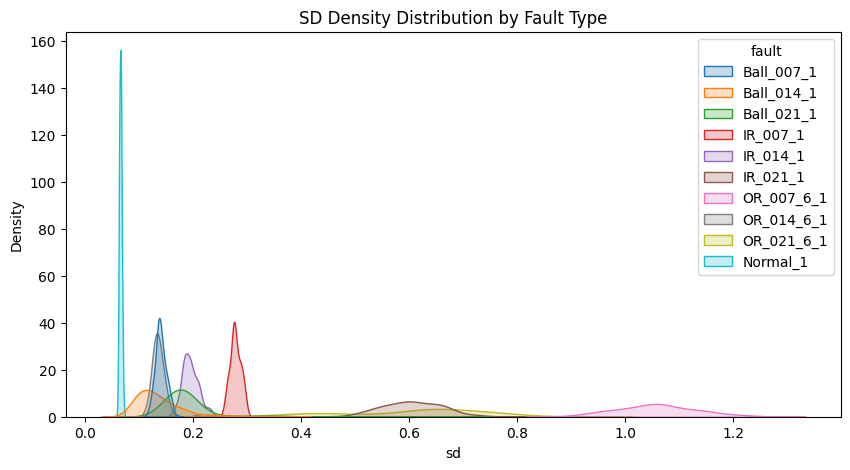

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='sd', hue='fault', common_norm=False, fill=True)
plt.title('SD Density Distribution by Fault Type')
plt.show()